<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [1]:
%pip install --upgrade --no-cache-dir gdown --quiet


Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q tensorflow tensorflow-metal

Note: you may need to restart the kernel to use updated packages.


In [3]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input

In [4]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU detectada:", gpus)
else:
    print("No se detectó GPU, se usará CPU")

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [6]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [7]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [8]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 30

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 6033


In [9]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

In [10]:
input_sentences

['hello ',
 'hi how are you ',
 'hi ',
 'hi ',
 'hi ',
 'where are you working ',
 'bro ',
 'where are you from ',
 'i am from russia and you ',
 'i hate them most of the time ',
 'i love disney movies ',
 'what is your favorite ',
 'i like reading do you ',
 'mee too ',
 'i like it a lot ',
 'cool i need to go see ya ',
 'hi bro ',
 'i m from dolgoprudny ',
 'organ ',
 'hi ',
 'hello how are you doing ',
 'what is tacos then ',
 'hi ',
 'hi',
 'who are you ',
 'cool where are you from ',
 'hi ',
 'hyperion',
 'hello there',
 'i help my father at the farm',
 'i don t like play video games',
 'oh what genre ',
 'thriller',
 'oh i hate horror movies ',
 'i should go buy',
 'hey there ',
 'i m not in the us ',
 'oh where are you from then ',
 'oh no sorry to hear that ',
 'but i m good now ',
 'what happened ',
 'it was a cancer',
 'thx you too ',
 'thank you anytime ',
 'bye',
 'hi ',
 'i m software developer ',
 'whanna know more ',
 'i dance drum and base ',
 'what team do you like ',


### ***Pueden realizar el desafio en Keras o PyTorch.***

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

**Tokenización de inputs (encoder)**

In [11]:
tokenizer_inputs = Tokenizer(filters="") # filters="" para no quitar signos adicionales de forma automática
tokenizer_inputs.fit_on_texts(input_sentences) # Aprende el vocabulario a partir de input_sentences

word2idx_inputs = tokenizer_inputs.word_index

In [12]:
word2idx_inputs

{'i': 1,
 'you': 2,
 'do': 3,
 'what': 4,
 'a': 5,
 'to': 6,
 'are': 7,
 'for': 8,
 'am': 9,
 'how': 10,
 'hi': 11,
 'like': 12,
 'living': 13,
 'love': 14,
 'is': 15,
 'have': 16,
 'm': 17,
 'that': 18,
 'hello': 19,
 'oh': 20,
 'your': 21,
 'ok': 22,
 'read': 23,
 'good': 24,
 'yes': 25,
 'the': 26,
 'it': 27,
 'not': 28,
 'no': 29,
 's': 30,
 'any': 31,
 'work': 32,
 'in': 33,
 'u': 34,
 'me': 35,
 'my': 36,
 'about': 37,
 'and': 38,
 'from': 39,
 't': 40,
 'of': 41,
 'go': 42,
 'play': 43,
 'today': 44,
 'too': 45,
 'so': 46,
 'don': 47,
 'hobbies': 48,
 'nice': 49,
 'fine': 50,
 'name': 51,
 'where': 52,
 'cool': 53,
 'doing': 54,
 'there': 55,
 'hey': 56,
 'know': 57,
 'bye': 58,
 'see': 59,
 'great': 60,
 'well': 61,
 'favorite': 62,
 'sure': 63,
 'old': 64,
 'games': 65,
 'pets': 66,
 'why': 67,
 'beach': 68,
 'sorry': 69,
 'at': 70,
 'nothing': 71,
 'mean': 72,
 'lot': 73,
 'fun': 74,
 'live': 75,
 'okay': 76,
 'thanks': 77,
 'also': 78,
 'can': 79,
 'student': 80,
 'city': 81

In [16]:
encoder_input_sequences = tokenizer_inputs.texts_to_sequences(input_sentences)

# Longitud máxima encontrada en las secuencias de entrada
max_input_len = max(len(s) for s in encoder_input_sequences)

# Padding para que todas las secuencias tengan la misma longitud
encoder_input_sequences = pad_sequences(
    encoder_input_sequences,
    maxlen=max_input_len,
    padding="post" # agrega ceros al final
)

**Tokenización de outputs (decoder)**

In [17]:
tokenizer_outputs = Tokenizer(filters="")

# Se entrena con output_sentences + output_sentences_inputs:
# decoder input: "<sos> ..."
# decoder output: "... <eos>"
tokenizer_outputs.fit_on_texts(output_sentences + output_sentences_inputs)

word2idx_outputs = tokenizer_outputs.word_index

num_words_output = len(word2idx_outputs) + 1 # + 1 por el índice 0 reservado al padding

# Secuencias que entran al decoder (con <sos>)
decoder_input_sequences = tokenizer_outputs.texts_to_sequences(output_sentences_inputs)

# Secuencias objetivo del decoder (con <eos>)
decoder_output_sequences = tokenizer_outputs.texts_to_sequences(output_sentences)

# Longitud máxima de secuencia de salida
max_out_len = max(len(s) for s in decoder_output_sequences)

# Padding en entradas del decoder
decoder_input_sequences = pad_sequences(
    decoder_input_sequences,
    maxlen=max_out_len,
    padding="post"
)

# Padding en salidas del decoder
decoder_output_sequences = pad_sequences(
    decoder_output_sequences,
    maxlen=max_out_len,
    padding="post"
)

**Targets one-hot para entrenamiento**

In [18]:
# decoder_targets: (n_muestras, max_out_len, num_words_output)
decoder_targets = np.zeros(
    (len(decoder_output_sequences), max_out_len, num_words_output),
    dtype="float32"
)

for i, seq in enumerate(decoder_output_sequences):

    for t, word_id in enumerate(seq):

        # Si word_id == 0 es padding
        if word_id != 0:
            decoder_targets[i, t, word_id] = 1.0

In [19]:
print("max_input_len:", max_input_len)
print("max_out_len:", max_out_len)
print("num_words_output:", num_words_output)
print("encoder_input_sequences:", encoder_input_sequences.shape)
print("decoder_output_sequences:", decoder_output_sequences.shape)
print("decoder_targets:", decoder_targets.shape)


max_input_len: 9
max_out_len: 10
num_words_output: 1807
encoder_input_sequences: (6033, 9)
decoder_output_sequences: (6033, 10)
decoder_targets: (6033, 10, 1807)


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [20]:
%pip install --quiet gensim

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import gensim.downloader as api
from tensorflow.keras.layers import Embedding

**Cargar GloVe preentrenado (100 dimensiones)**

In [58]:
glove_vectors = api.load("glove-wiki-gigaword-100")
embedding_dim = glove_vectors.vector_size

**Cargar Fasttext preentrenado (300 dimensiones)**

In [56]:
fasttext_model = api.load("fasttext-wiki-news-subwords-300")
embedding_dim = 300

# Sobreescribe el embedding glova (modelo ya entrenado con este embedding)

[==================================================] 100.0% 958.5/958.4MB downloaded


**Contrucción de la matriz de embeddings (GloVe)**

In [ ]:
num_words_input = len(word2idx_inputs) + 1
rng = np.random.default_rng(42)

embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(num_words_input, embedding_dim)
).astype(np.float32)
embedding_matrix[0] = 0.0  # padding en cero

hits, misses = 0, 0
for word, idx in word2idx_inputs.items():
    if idx >= num_words_input:
        continue
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        hits += 1
    else:
        misses += 1

print(f"Embeddings encontrados: {hits}")
print(f"Palabras no encontradas: {misses}")
print("embedding_matrix shape:", embedding_matrix.shape)

Embeddings encontrados: 1636
Palabras no encontradas: 168
embedding_matrix shape: (1805, 100)


**Contrucción de la matriz de embeddings (FastText)**

In [63]:
num_words_input = len(word2idx_inputs) + 1
rng = np.random.default_rng(42)

embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(num_words_input, embedding_dim)
).astype(np.float32)
embedding_matrix[0] = 0.0  # padding

hits, misses = 0, 0
for word, idx in word2idx_inputs.items():
    if idx >= num_words_input:
        continue
    try:
        embedding_matrix[idx] = fasttext_model.get_vector(word)
        hits += 1
    except KeyError:
        misses += 1

print(f"Embeddings cargados: {hits}")
print(f"Palabras no encontradas: {misses}")
print("embedding_matrix shape:", embedding_matrix.shape)

Embeddings cargados: 1645
Palabras no encontradas: 159
embedding_matrix shape: (1805, 300)


In [64]:
# Para mejorar la comprensión semántica:
# (N, max_input_len) -> (N, max_input_len, embedding_dim)
encoder_input_embeddings = embedding_matrix[encoder_input_sequences]
print("encoder_input_embeddings shape:", encoder_input_embeddings.shape)

encoder_input_embeddings shape: (6033, 9, 300)


In [65]:
encoder_embedding_layer = Embedding(
    input_dim=num_words_input,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False,
    name="encoder_embedding"
)

### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

**Entrenamiento en Keras**

Se implementa la arquitectura encoder-decoder con LSTM.

1. El encoder recibe las secuencias de entrada (tokens de las preguntas), pasa por los embeddings preentrenados de GloVe y por un LSTM.
2. La salida del encoder es una representación comprimida (vectorial) de las preguntas -> espacio latente.
3. El decoder genera las palabras a partir de la representación latente y selecciona cada palabra a partir de una Softmax.

In [66]:
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Embedding, AdditiveAttention, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os

In [67]:
num_words_input = len(word2idx_inputs) + 1
latent_dim = 512 # dimensión del espacio latente

**Split del dataset**

In [68]:
Xenc_train, Xenc_val, Xdec_train, Xdec_val, decoder_output_sequences_train, decoder_output_sequences_val = train_test_split(
    encoder_input_sequences,
    decoder_input_sequences,
    decoder_output_sequences,
    test_size=0.2,
    random_state=42
)

**Encoder**

In [69]:
encoder_inputs = Input(shape=(max_input_len,), name="encoder_inputs")

encoder_embedding = Embedding(
        input_dim=num_words_input,
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True,
        name="encoder_embedding"
    )

encoder_x = encoder_embedding(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state = True,
    use_cudnn = False, # Evitar error en el entrenamiento 
    name="encoder_lstm"
    )

encoder_outputs, state_h, state_c = encoder_lstm(encoder_x)
encoder_states = [state_h, state_c]

**Decoder**

In [70]:
decoder_inputs = Input(shape=(max_out_len,), name="decoder_inputs")
decoder_embedding = Embedding(
    input_dim=num_words_output,
    output_dim=latent_dim,
    trainable=True,
    mask_zero=True,
    name="decoder_embedding"
)

decoder_x = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    dropout=0.2,
    use_cudnn=False, # para evitar error en el entrenamiento
    name="decoder_lstm",
)

decoder_outputs, _, _ = decoder_lstm(decoder_x, initial_state=encoder_states)

decoder_dense = Dense(num_words_output, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

**Contrucción del encoder-decoder**

In [71]:
training_model = Model([encoder_inputs, decoder_inputs], decoder_outputs, name="seq2seq_train")
# training_model.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
)

In [72]:
training_model.summary()

Model: "seq2seq_train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 9, 300)    │    541,500 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 9)         │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 10, 512)   │    925,184 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 512),     │  1,665,024 │ encoder_embeddin… │
│                     │ (None, 512),      │            │ not_equal_3[0][0] │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 512), │  2,099,200 │ decoder_embeddin… │
│                     │ (None, 512),      │            │ encoder_lstm[0][… │
│                     │ (None, 512)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 10, 1807)  │    926,991 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,157,899 (23.49 MB)

 Trainable params: 5,616,399 (21.42 MB)

 Non-trainable params: 541,500 (2.07 MB)

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

#### Modelo con embeddings GloVe

In [34]:
y_train_sparse = decoder_output_sequences_train
y_val_sparse = decoder_output_sequences_val

# máscara de padding (0 = pad)
sw_train = (y_train_sparse != 0).astype("float32")
sw_val = (y_val_sparse != 0).astype("float32")

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
)

history = training_model.fit(
    [Xenc_train, Xdec_train],
    y_train_sparse,
    sample_weight=sw_train,
    validation_data=([Xenc_val, Xdec_val], y_val_sparse, sw_val),
    batch_size=64,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


2026-04-22 19:18:05.932129: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - acc: 0.0941 - loss: 6.0539 - val_acc: 0.1255 - val_loss: 4.3533
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.1392 - loss: 4.1114 - val_acc: 0.1762 - val_loss: 3.8852
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.1929 - loss: 3.5924 - val_acc: 0.2095 - val_loss: 3.5640
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.2167 - loss: 3.2974 - val_acc: 0.2188 - val_loss: 3.3788
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.2332 - loss: 3.0487 - val_acc: 0.2266 - val_loss: 3.2635
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 192ms/step - acc: 0.2409 - loss: 2.9481 - val_acc: 0.2334 - val_loss: 3.1703
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.2431 - loss: 2.8600 - val_acc: 0.2373 - val_loss: 3.1105
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - acc: 0.2481 - loss: 2.7148 - val_acc: 0.2408 - val_loss: 3.0583
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/ste

**Graficar la evoluación del entrenmiento**

In [35]:
import os
import matplotlib.pyplot as plt

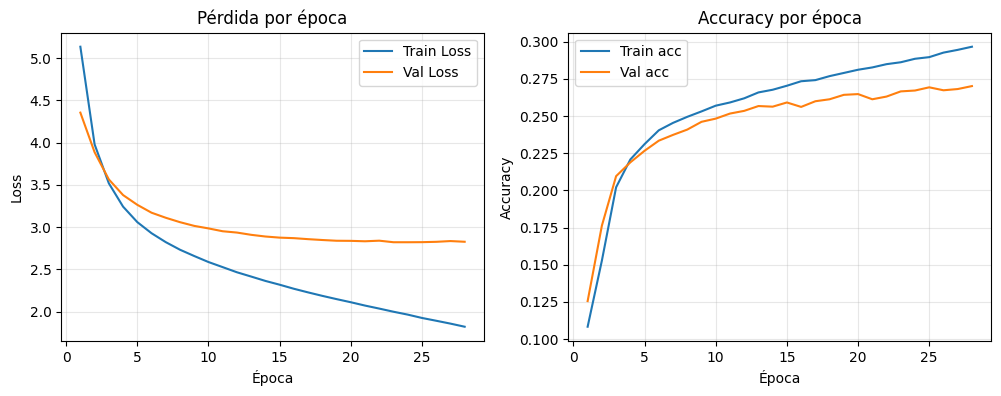

In [36]:
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, hist["loss"], label="Train Loss")

plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

acc_key = next(
    (k for k in ["accuracy", "acc", "categorical_accuracy", "sparse_categorical_accuracy"] if k in hist),
    None
)

plt.subplot(1, 2, 2)
plt.plot(epochs, hist[acc_key], label=f"Train {acc_key}")
val_acc_key = f"val_{acc_key}"
plt.plot(epochs, hist[val_acc_key], label=f"Val {acc_key}")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

**Guardar modelo**

In [55]:
model_path = "seq2seq_train_glove.keras"

training_model.save(model_path)

#### Modelo con embeddings FastText

In [73]:
y_train_sparse = decoder_output_sequences_train
y_val_sparse = decoder_output_sequences_val

# máscara de padding (0 = pad)
sw_train = (y_train_sparse != 0).astype("float32")
sw_val = (y_val_sparse != 0).astype("float32")

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
)

history = training_model.fit(
    [Xenc_train, Xdec_train],
    y_train_sparse,
    sample_weight=sw_train,
    validation_data=([Xenc_val, Xdec_val], y_val_sparse, sw_val),
    batch_size=64,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - acc: 0.0942 - loss: 6.2923 - val_acc: 0.1273 - val_loss: 4.3532
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/step - acc: 0.1415 - loss: 4.0839 - val_acc: 0.1566 - val_loss: 3.9292
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - acc: 0.1842 - loss: 3.6149 - val_acc: 0.2038 - val_loss: 3.6076
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - acc: 0.2140 - loss: 3.3313 - val_acc: 0.2164 - val_loss: 3.4188
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/step - acc: 0.2200 - loss: 3.1601 - val_acc: 0.2242 - val_loss: 3.3060
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 194ms/step - acc: 0.2336 - loss: 2.9733 - val_acc: 0.2310 - val_loss: 3.2171
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - acc: 0.2363 - loss: 2.8876 - val_acc: 0.2383 - val_loss: 3.1527
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/step - acc: 0.2453 - loss: 2.7840 - val_acc: 0.2397 - val_loss: 3.0967
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1

**Graficar la evoluación del entrenmiento**

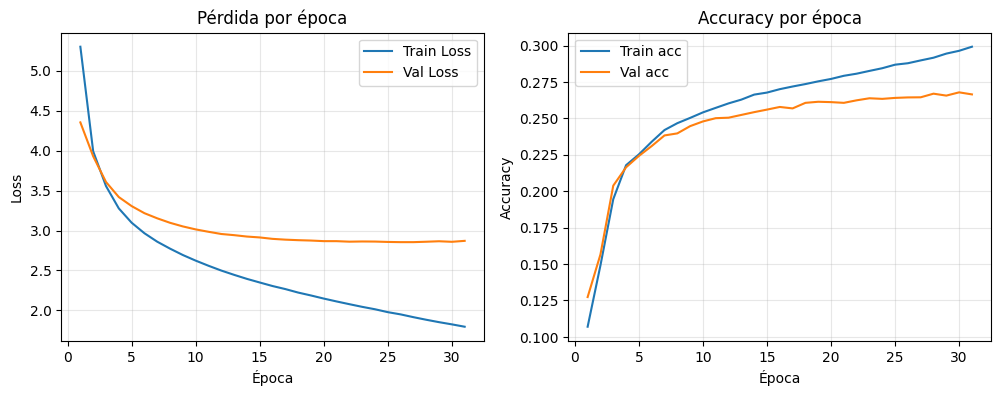

In [74]:
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, hist["loss"], label="Train Loss")

plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

acc_key = next(
    (k for k in ["accuracy", "acc", "categorical_accuracy", "sparse_categorical_accuracy"] if k in hist),
    None
)

plt.subplot(1, 2, 2)
plt.plot(epochs, hist[acc_key], label=f"Train {acc_key}")
val_acc_key = f"val_{acc_key}"
plt.plot(epochs, hist[val_acc_key], label=f"Val {acc_key}")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

**Guardar modelo**

In [75]:
model_path = "seq2seq_train_fasttext.keras"

training_model.save(model_path)

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [38]:
import numpy as np
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import pad_sequences

In [39]:
# Diccionarios inversos índice -> palabra
idx2word_inputs = {i: w for w, i in word2idx_inputs.items()}
idx2word_outputs = {i: w for w, i in word2idx_outputs.items()}

**Modelo encoder para inferencia**

In [40]:
encoder_model = Model(encoder_inputs, encoder_states)

**Modelo decoder para inferencia**

In [41]:
latent_dim_inf = encoder_lstm.units # usa la dimensión real del LSTM entrenado

decoder_state_input_h = Input(shape=(latent_dim_inf,), name="decoder_state_input_h")
decoder_state_input_c = Input(shape=(latent_dim_inf,), name="decoder_state_input_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Entrada de 1 token por paso temporal
decoder_single_input = Input(shape=(1,), name="decoder_single_input")

dec_emb = decoder_embedding(decoder_single_input)
dec_outputs, state_h, state_c = decoder_lstm(
    dec_emb,
    initial_state=decoder_states_inputs
)
dec_outputs = decoder_dense(dec_outputs)
decoder_states = [state_h, state_c]

decoder_model = Model(
    [decoder_single_input] + decoder_states_inputs,
    [dec_outputs] + decoder_states
)

**Decodificación con temperatura**

In [ ]:
def sample_with_temperature(probabilities, temperature=1.0):
    p = np.asarray(probabilities).astype("float64")
    if temperature <= 0:
        return int(np.argmax(p))
    p = np.log(np.clip(p, 1e-12, 1.0)) / temperature
    p = np.exp(p - np.max(p))
    p = p / np.sum(p)
    return int(np.random.choice(len(p), p=p))

def decode_sequence(input_seq, temperature=0.8):
    enc = encoder_model.predict(input_seq, verbose=0)

    # Compatible con ambos casos:
    # - sin attention: encoder_model -> [h, c]
    # - con attention: encoder_model -> [encoder_outputs, h, c]
    if isinstance(enc, list) and len(enc) == 3:
        use_attention = True
        encoder_outputs_value, h, c = enc
    else:
        use_attention = False
        h, c = enc

    sos_id = word2idx_outputs["<sos>"]
    eos_id = word2idx_outputs["<eos>"]

    target_seq = np.array([[sos_id]], dtype="int32")
    decoded_tokens = []

    for _ in range(max_out_len):
        if use_attention:
            output_tokens, h, c = decoder_model.predict(
                [target_seq, encoder_outputs_value, h, c], verbose=0
            )
        else:
            output_tokens, h, c = decoder_model.predict(
                [target_seq, h, c], verbose=0
            )

        probs = output_tokens[0, -1, :]
        sampled_id = sample_with_temperature(probs, temperature)

        if sampled_id == 0:  # evita PAD
            sampled_id = int(np.argmax(probs[1:]) + 1)

        sampled_word = idx2word_outputs.get(sampled_id, "")
        if sampled_id == eos_id or sampled_word == "":
            break
        if sampled_word != "<sos>":
            decoded_tokens.append(sampled_word)

        target_seq = np.array([[sampled_id]], dtype="int32")

    return " ".join(decoded_tokens)

#### Inferencia del modelo con embeddings GloVe

In [52]:
def responder(texto_usuario, temperature=0.8):
    texto_limpio = clean_text(texto_usuario)
    seq = tokenizer_inputs.texts_to_sequences([texto_limpio])
    seq = pad_sequences(seq, maxlen=max_input_len, padding="post", truncating="post")
    return decode_sequence(seq, temperature)

In [49]:
input_sentences[:10]

['hello ',
 'hi how are you ',
 'hi ',
 'hi ',
 'hi ',
 'where are you working ',
 'bro ',
 'where are you from ',
 'i am from russia and you ',
 'i hate them most of the time ']

**Modelo entrenado con embeddings de GloVe**

In [54]:
preguntas = [
    "hello",
    "hi sweety",
    "how are you",
    "what is your name",
    "how old are you",
    "do you have a pet",
    "i have a cat",
    "whats your name",
    "what do you do for a living",

    "where are you from",
    "i am from argentina and you",

    
    "what is your favorite color",
    "what is your favorite food",
    "what is your favorite place",

    "tomorrow i will go to the nutricionist",
    "my name is santiago",
    "my cat loves his box",
]

for i, q in enumerate(preguntas, start=1):
    print(f"\nPregunta {i}: {q}")
    print(f"Respuesta {i}: {responder(q, temperature = 0.5)}")



Pregunta 1: hello
Respuesta 1: hello how are you

Pregunta 2: hi sweety
Respuesta 2: hello how are you

Pregunta 3: how are you
Respuesta 3: i am fine

Pregunta 4: what is your name
Respuesta 4: i like to go to the beach

Pregunta 5: how old are you
Respuesta 5: i am fine

Pregunta 6: do you have a pet
Respuesta 6: i love to read

Pregunta 7: i have a cat
Respuesta 7: what do you do for work

Pregunta 8: whats your name
Respuesta 8: what is your favorite food

Pregunta 9: what do you do for a living
Respuesta 9: i am a student

Pregunta 10: where are you from
Respuesta 10: i am doing well how are you

Pregunta 11: i am from argentina and you
Respuesta 11: i m a vegan

Pregunta 12: what is your favorite color
Respuesta 12: no

Pregunta 13: what is your favorite food
Respuesta 13: i like to go to the beach

Pregunta 14: what is your favorite place
Respuesta 14: i like to play video games

Pregunta 15: tomorrow i will go to the nutricionist
Respuesta 15: oh i m good

Pregunta 16: my name

#### Inferencia del modelo con embeddings FastText

In [76]:
def responder(texto_usuario, temperature=0.8):
    texto_limpio = clean_text(texto_usuario)
    seq = tokenizer_inputs.texts_to_sequences([texto_limpio])
    seq = pad_sequences(seq, maxlen=max_input_len, padding="post", truncating="post")
    return decode_sequence(seq, temperature)

In [77]:
preguntas = [
    "hello",
    "hi sweety",
    "how are you",
    "what is your name",
    "how old are you",
    "do you have a pet",
    "i have a cat",
    "whats your name",
    "what do you do for a living",

    "where are you from",
    "i am from argentina and you",

    
    "what is your favorite color",
    "what is your favorite food",
    "what is your favorite place",

    "tomorrow i will go to the nutricionist",
    "my name is santiago",
    "my cat loves his box",
]

for i, q in enumerate(preguntas, start=1):
    print(f"\nPregunta {i}: {q}")
    print(f"Respuesta {i}: {responder(q, temperature = 0.5)}")



Pregunta 1: hello
Respuesta 1: hello how are you

Pregunta 2: hi sweety
Respuesta 2: hello how are you

Pregunta 3: how are you
Respuesta 3: i am fine

Pregunta 4: what is your name
Respuesta 4: i m a vegan

Pregunta 5: how old are you
Respuesta 5: i m fine

Pregunta 6: do you have a pet
Respuesta 6: i want to go to the beach

Pregunta 7: i have a cat
Respuesta 7: i am a vegan i love it

Pregunta 8: whats your name
Respuesta 8: what do you do for a living

Pregunta 9: what do you do for a living
Respuesta 9: i am a famous person

Pregunta 10: where are you from
Respuesta 10: thanks

Pregunta 11: i am from argentina and you
Respuesta 11: what do you do for a living

Pregunta 12: what is your favorite color
Respuesta 12: i work at a grocery store

Pregunta 13: what is your favorite food
Respuesta 13: i like to play video games

Pregunta 14: what is your favorite place
Respuesta 14: thanks

Pregunta 15: tomorrow i will go to the nutricionist
Respuesta 15: what do you do for a living

Pre

### Conclusiones

En el entrenamiento, el modelo converge en ambos casos alrededor de las época 30, pero con una brecha entre entrenamiento y validación, señal de overfiting moderado.

La métrica usada es accuracy por token. El comportamiento observado (respuestas genéricas/repetidas) indica que el modelo aprende patrones frecuentes del dataset, pero le cuesta generalizar en preguntas menos comunes o con contexto personal.

En cuanto a los embeddings: FastText ajustó mejor al entrenamiento, pero no generalizó mejor. En el experimento, GloVe fue más estable para validación.

Analizando la inferencia, se observa que saludos y preguntas muy frecuentes (hello, how are you, algunos patrones de trabajo/estudios) los responde bien. Por otro lado, realiza respuestas fuera de contexto, repetición, y colapso a frases frecuentes (“what do you do for a living”, “thanks”, “i am a vegan”).

En FastText, ese colapso aparece más marcado mientras que en GloVe hay algo más de variedad, aunque sigue habiendo errores semánticos.

Por lo tanto, para este dataset y arquitectura encoder-decoder, GloVe (100d) resulta la mejor opción de las dos probadas y subir a FastText 300d no aportó mejora real en generalización.

El límite principal no parece ser solo el embedding, sino la combinación de tamaño/calidad de datos.